💡 **Environment:** `clamp-analyses`

# Description

**Pooled early-enrichment summary + paired bootstrap.** Consumes `early_enrichment_observed.csv` (from `00_early_enrichment_metrics.ipynb`) and re-reads `../signif_test/predictions_paired.pkl`.

We (1) bootstrap each of the 7 early-enrichment metrics (BEDROC, EF@1/5/10%, P@10/20/50) and (2) test the 6 pairwise method differences with a **paired bootstrap**, exactly as in `../signif_test`: one resample of the **685 pairs** per iteration, applied to *every* method; differences taken by subtraction (`diff = method_b − method_a`), so cross-method correlation cancels. CI + two-sided bootstrap p-value, **BH-corrected within each metric family** (each metric is its own family of 6 comparisons → 7 × 6 = 42 rows).

**Headline = BEDROC(α=20).** It is continuous and weights the top ~5%; EF and precision@k are coarse interpretability companions.

**Caveat (carried from NB00).** Pooled base rate ≈ 0.775 → BEDROC null ≈ 0.775 (not 0.5), EF ceiling ≈ 1.29, precision@k null ≈ 0.775. Read **differences**, not absolute enrichment.

Helpers `boot_ci` / `boot_pvalue_two_sided` / `bh_correct` are **copied verbatim from `../signif_test/01_paired_bootstrap_test.ipynb`** (not imported) to keep the directory isolated.

# Modules loading

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import itertools
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyprojroot import here

# Settings

In [3]:
SEED = 42
N_BOOT = 10000

# Same fixed order / sign convention as ../signif_test: for a comparison (A, B),
# diff = B - A. gene_based first -> module-vs-gene rows read 'module - gene'.
METHOD_ORDER = [
    'gene_based',
    'module_based_archs4',
    'module_based_gtex',
    'module_based_recount2',
]
COMPARISONS = list(itertools.combinations(METHOD_ORDER, 2))   # 6 pairwise

BEDROC_ALPHA = 20.0
EF_CHIS = [0.01, 0.05, 0.10]
PK_KS = [10, 20, 50]
METRIC_ORDER = ['BEDROC', 'EF@1%', 'EF@5%', 'EF@10%', 'P@10', 'P@20', 'P@50']

METHOD_LABEL = {
    'gene_based': 'gene',
    'module_based_archs4': 'ARCHS4',
    'module_based_gtex': 'GTEx',
    'module_based_recount2': 'recount2',
}
METHOD_COLOR = {
    'gene_based': '#444444',
    'module_based_archs4': '#1f77b4',
    'module_based_gtex': '#2ca02c',
    'module_based_recount2': '#d62728',
}

INPUT_PKL = here(
    'output/03_model_biology/00_archs4/02_drug_disease_associations/'
    'signif_test/predictions_paired.pkl')
OUTPUT_DIR = here(
    'output/03_model_biology/00_archs4/02_drug_disease_associations/early_enrichment_test')
FIG_DIR = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
display(OUTPUT_DIR)

PosixPath('/home/miltondp/projects/clamp/clamp-analyses/output/03_model_biology/00_archs4/02_drug_disease_associations/early_enrichment_test')

# Metric helpers (same as NB00; re-pasted to keep the directory isolated)

In [4]:
def bedroc_score(y_true, scores, alpha=20.0):
    """BEDROC (Truchon & Bajorath 2007). Higher score => more likely positive.
    [0, 1]: random -> base rate (Ra), perfect -> 1, worst -> 0. Stable-sort ties."""
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores, dtype=float)
    N = len(y_true)
    n = int(y_true.sum())
    if n == 0 or n == N:
        return np.nan
    order = np.argsort(-scores, kind='stable')
    active_ranks = np.where(y_true[order] == 1)[0] + 1
    Ra = n / N
    s = np.sum(np.exp(-alpha * active_ranks / N))
    rie_denom = (1.0 / N) * (1 - np.exp(-alpha)) / (np.exp(alpha / N) - 1)
    rie = (s / n) / rie_denom
    return (rie * Ra * np.sinh(alpha / 2)
            / (np.cosh(alpha / 2) - np.cosh(alpha / 2 - alpha * Ra))
            + 1.0 / (1 - np.exp(alpha * (1 - Ra))))


def precision_at_k(y_true, scores, k):
    order = np.argsort(-scores, kind='stable')
    return float(np.asarray(y_true).astype(int)[order[:k]].mean())


def enrichment_factor(y_true, scores, chi):
    y_true = np.asarray(y_true).astype(int)
    N = len(y_true)
    n = int(y_true.sum())
    K = int(np.ceil(chi * N))
    order = np.argsort(-scores, kind='stable')
    return (int(y_true[order[:K]].sum()) / K) / (n / N)

# Load predictions + observed metrics

In [5]:
predictions = pd.read_pickle(INPUT_PKL)
assert not predictions.isna().any().any(), 'unexpected NaNs in predictions_paired.pkl'
pair_sets = {
    m: set(map(tuple, g[['trait', 'drug']].itertuples(index=False, name=None)))
    for m, g in predictions.groupby('method', observed=True)
}
ref = pair_sets[METHOD_ORDER[0]]
for m in METHOD_ORDER[1:]:
    assert pair_sets[m] == ref, f'{m} covers a different (trait, drug) set'
lbl = predictions.groupby(['trait', 'drug'], observed=True)['true_class'].nunique()
assert (lbl == 1).all(), 'true_class disagrees across methods'

wide = predictions.pivot_table(
    index=['trait', 'drug'], columns='method', values='score', observed=True)[METHOD_ORDER]
y_true = predictions.pivot_table(
    index=['trait', 'drug'], columns='method', values='true_class',
    observed=True).iloc[:, 0].values.astype(int)
scores = {m: wide[m].values for m in METHOD_ORDER}
n = len(y_true)
n_pos = int(y_true.sum())
base_rate = n_pos / n
EF_MAX = 1.0 / base_rate

observed = pd.read_csv(OUTPUT_DIR / 'early_enrichment_observed.csv')
display(f'{n} pairs, base rate {base_rate:.4f}, EF ceiling {EF_MAX:.4f}')
display(observed.pivot_table(index='metric', columns='method', values='value', observed=True)
        .reindex(METRIC_ORDER).round(4))

'685 pairs, base rate 0.7752, EF ceiling 1.2900'

method,gene_based,module_based_archs4,module_based_gtex,module_based_recount2
metric,,,,
BEDROC,0.9438,0.9016,0.8895,0.9101
EF@1%,1.2900,1.2900,1.2900,1.2900
EF@5%,1.2163,1.2163,1.1794,1.1794
EF@10%,1.2152,1.1591,1.1405,1.1778
P@10,1.0000,1.0000,0.9000,1.0000
P@20,0.9500,0.9000,0.8500,0.9500
P@50,0.9600,0.9000,0.9200,0.9000


# Helpers (copied verbatim from `../signif_test/01_paired_bootstrap_test.ipynb`)

In [6]:
def boot_ci(arr, lo=2.5, hi=97.5):
    return np.percentile(arr, lo), np.percentile(arr, hi)


def boot_pvalue_two_sided(diffs):
    """Two-sided bootstrap p-value for H0: diff == 0.

    Uses the (count + 1) / (N + 1) convention (Davison & Hinkley 1997) so the
    p-value is never exactly 0 -- it is floored at 2 / (N + 1).
    """
    n = len(diffs)
    p_le = ((diffs <= 0).sum() + 1) / (n + 1)
    p_ge = ((diffs >= 0).sum() + 1) / (n + 1)
    return min(2.0 * min(p_le, p_ge), 1.0)


def bh_correct(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = ranked * m / (np.arange(m) + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    out = np.empty(m)
    out[order] = np.minimum(adj, 1.0)
    return out

# Build the 7 metric callables

Each closure captures its own cut (no late-binding bug). `NULL_VALUE` records the null baseline per metric for the plots / FINDINGS: BEDROC and precision@k null = base rate; EF null = 1.

In [7]:
METRICS = {'BEDROC': lambda y, s: bedroc_score(y, s, BEDROC_ALPHA)}
for _chi in EF_CHIS:
    METRICS[f'EF@{int(round(_chi * 100))}%'] = (
        lambda c: lambda y, s: enrichment_factor(y, s, c))(_chi)
for _k in PK_KS:
    METRICS[f'P@{_k}'] = (lambda kk: lambda y, s: precision_at_k(y, s, kk))(_k)
METRICS = {name: METRICS[name] for name in METRIC_ORDER}   # fix order

NULL_VALUE = {'BEDROC': base_rate}
NULL_VALUE.update({f'EF@{int(round(c * 100))}%': 1.0 for c in EF_CHIS})
NULL_VALUE.update({f'P@{k}': base_rate for k in PK_KS})
display(list(METRICS))

['BEDROC', 'EF@1%', 'EF@5%', 'EF@10%', 'P@10', 'P@20', 'P@50']

# Paired bootstrap

One resample of the 685 **pairs** per iteration, reused across every method (paired); diffs by subtraction. Single-class resamples (both classes needed for every metric) are skipped — at 77.5% prevalence this is essentially never triggered, but kept for parity with `../signif_test`.

In [8]:
np.random.seed(SEED)

# Bootstrap each metric ONCE per resample, reusing the SAME resampled pair indices
# across every method. Pairwise diffs are taken by subtraction afterward (valid
# because the per-method arrays are aligned iteration-by-iteration to the same
# resample) -- the paired-test requirement, identical to ../signif_test.
boot_metric = {mname: {m: [] for m in METHOD_ORDER} for mname in METRICS}
n_skipped = 0

for _ in range(N_BOOT):
    idx = np.random.choice(n, n, replace=True)   # same resample for every method
    yb = y_true[idx]
    if len(np.unique(yb)) < 2:                    # metrics undefined on a single class
        n_skipped += 1
        continue
    for mname, mfunc in METRICS.items():
        for m in METHOD_ORDER:
            boot_metric[mname][m].append(mfunc(yb, scores[m][idx]))

boot_metric = {mname: {m: np.asarray(v) for m, v in d.items()}
               for mname, d in boot_metric.items()}
display(f'Bootstrap iterations used: {N_BOOT - n_skipped} '
        f'(skipped {n_skipped} single-class resamples)')

'Bootstrap iterations used: 10000 (skipped 0 single-class resamples)'

# Results: CI + bootstrap p-value on each pairwise difference

In [9]:
midx = {m: i for i, m in enumerate(METHOD_ORDER)}
# Observed (point) metric per method on the full pooled list.
obs_metric = {mname: {m: METRICS[mname](y_true, scores[m]) for m in METHOD_ORDER}
              for mname in METRICS}

rows = []
for mname in METRICS:
    for method_a, method_b in COMPARISONS:
        boot_a = boot_metric[mname][method_a]
        boot_b = boot_metric[mname][method_b]
        boot_diff = boot_b - boot_a            # paired: same resample per iteration
        a_lo, a_hi = boot_ci(boot_a)
        b_lo, b_hi = boot_ci(boot_b)
        diff_lo, diff_hi = boot_ci(boot_diff)
        rows.append({
            'metric': mname,
            'comparison': f'{method_b} vs {method_a}',
            'method_a': method_a, 'method_b': method_b,
            'a_obs': obs_metric[mname][method_a], 'a_lo': a_lo, 'a_hi': a_hi,
            'b_obs': obs_metric[mname][method_b], 'b_lo': b_lo, 'b_hi': b_hi,
            'diff_obs': obs_metric[mname][method_b] - obs_metric[mname][method_a],
            'diff_boot_mean': boot_diff.mean(),
            'diff_ci_lo': diff_lo, 'diff_ci_hi': diff_hi,
            'ci_excludes_0': bool(diff_lo > 0 or diff_hi < 0),
            'p_value': boot_pvalue_two_sided(boot_diff),
        })
results = pd.DataFrame(rows)

# BH WITHIN each metric family (each of the 7 metrics = one family of 6 comparisons).
results['p_value_bh'] = results.groupby('metric', sort=False)['p_value'].transform(bh_correct)
results['metric'] = pd.Categorical(results['metric'], categories=METRIC_ORDER, ordered=True)
results = results.sort_values(['metric', 'comparison']).reset_index(drop=True)

out_csv = OUTPUT_DIR / 'early_enrichment_bootstrap_results.csv'
out_pkl = OUTPUT_DIR / 'early_enrichment_bootstrap_results.pkl'
results.to_csv(out_csv, index=False)
results.to_pickle(out_pkl)
display(out_csv)
display(f'{len(results)} rows ({len(METRICS)} metrics x {len(COMPARISONS)} comparisons)')

# Headline BEDROC view, sorted by corrected p.
display(results[results['metric'] == 'BEDROC']
        .sort_values('p_value_bh')
        [['comparison', 'a_obs', 'b_obs', 'diff_obs', 'diff_ci_lo', 'diff_ci_hi',
          'ci_excludes_0', 'p_value', 'p_value_bh']].reset_index(drop=True).round(4))

PosixPath('/home/miltondp/projects/clamp/clamp-analyses/output/03_model_biology/00_archs4/02_drug_disease_associations/early_enrichment_test/early_enrichment_bootstrap_results.csv')

'42 rows (7 metrics x 6 comparisons)'

,comparison,a_obs,b_obs,diff_obs,diff_ci_lo,diff_ci_hi,ci_excludes_0,p_value,p_value_bh
0,module_based_archs4 vs gene_based,0.9438,0.9016,-0.0421,-0.1049,0.0113,False,0.1356,0.3279
1,module_based_gtex vs gene_based,0.9438,0.8895,-0.0542,-0.1317,0.0140,False,0.1378,0.3279
2,module_based_recount2 vs gene_based,0.9438,0.9101,-0.0337,-0.0932,0.0192,False,0.2178,0.3279
3,module_based_recount2 vs module_based_gtex,0.8895,0.9101,0.0205,-0.0101,0.0566,False,0.2186,0.3279
4,module_based_gtex vs module_based_archs4,0.9016,0.8895,-0.0121,-0.0510,0.0245,False,0.5353,0.5997
5,module_based_recount2 vs module_based_archs4,0.9016,0.9101,0.0084,-0.0248,0.0408,False,0.5997,0.5997


# Plots

Bootstrap distributions (box = sampling uncertainty of the statistic) with the observed point as a white diamond and the correct null as a red dashed line, plus a per-metric forest of pairwise differences.

/tmp/ipykernel_94430/731116266.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bdf, x='method', y='bedroc', order=order, ax=ax,
/tmp/ipykernel_94430/731116266.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


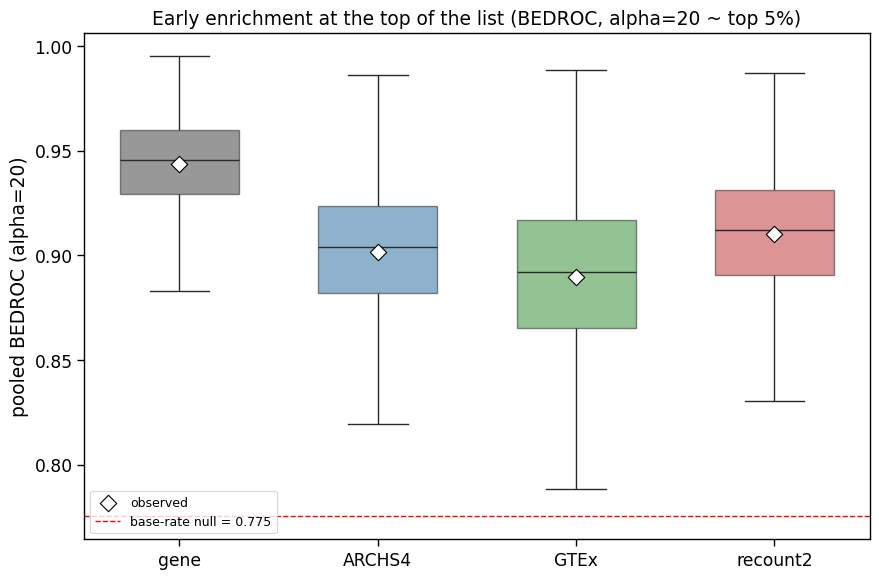

In [10]:
order = METHOD_ORDER
palette = [METHOD_COLOR[m] for m in order]
labels = [METHOD_LABEL[m] for m in order]

# --- BEDROC bootstrap distribution (headline) ---
bdf = pd.DataFrame({m: boot_metric['BEDROC'][m] for m in order}).melt(
    var_name='method', value_name='bedroc')
with sns.plotting_context('paper', font_scale=1.4):
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.boxplot(data=bdf, x='method', y='bedroc', order=order, ax=ax,
                palette=palette, showfliers=False, width=0.6, boxprops=dict(alpha=0.55))
    obs = [obs_metric['BEDROC'][m] for m in order]
    ax.scatter(range(len(order)), obs, marker='D', s=70, color='white',
               edgecolor='black', zorder=10, label='observed')
    ax.axhline(base_rate, color='red', linestyle='--', linewidth=1,
               label=f'base-rate null = {base_rate:.3f}')
    ax.set_xticklabels(labels)
    ax.set_xlabel('')
    ax.set_ylabel(f'pooled BEDROC (alpha={BEDROC_ALPHA:.0f})')
    ax.set_title('Early enrichment at the top of the list (BEDROC, alpha=20 ~ top 5%)')
    ax.legend(loc='lower left', fontsize=9)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'early_enrichment_bedroc_dist.png', dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()

/tmp/ipykernel_94430/760487504.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='method', y='ef', order=order, ax=ax,
/tmp/ipykernel_94430/760487504.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/tmp/ipykernel_94430/760487504.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='method', y='ef', order=order, ax=ax,
/tmp/ipykernel_94430/760487504.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/tmp/ipykernel_94430/760487504.py:9: FutureWar

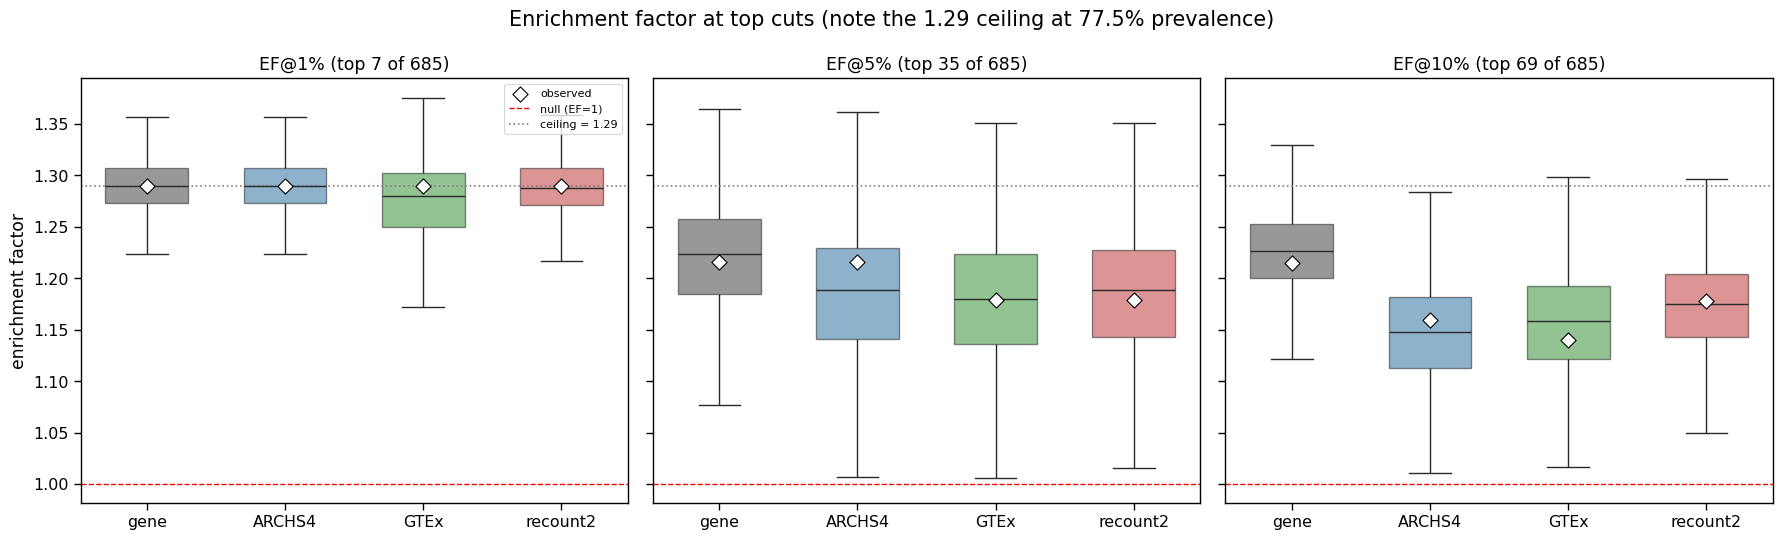

In [11]:
# --- Enrichment factor bootstrap distributions, faceted by chi ---
ef_names = [f'EF@{int(round(c * 100))}%' for c in EF_CHIS]
with sns.plotting_context('paper', font_scale=1.3):
    fig, axes = plt.subplots(1, len(ef_names), figsize=(6 * len(ef_names), 5.5), sharey=True)
    axes = list(np.atleast_1d(axes))
    for ax, name, chi in zip(axes, ef_names, EF_CHIS):
        d = pd.DataFrame({m: boot_metric[name][m] for m in order}).melt(
            var_name='method', value_name='ef')
        sns.boxplot(data=d, x='method', y='ef', order=order, ax=ax,
                    palette=palette, showfliers=False, width=0.6, boxprops=dict(alpha=0.55))
        obs = [obs_metric[name][m] for m in order]
        ax.scatter(range(len(order)), obs, marker='D', s=60, color='white',
                   edgecolor='black', zorder=10, label='observed')
        ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='null (EF=1)')
        ax.axhline(EF_MAX, color='grey', linestyle=':', linewidth=1.2,
                   label=f'ceiling = {EF_MAX:.2f}')
        ax.set_title(f'{name} (top {int(np.ceil(chi * n))} of {n})')
        ax.set_xlabel('')
        ax.set_xticklabels(labels)
        ax.set_ylabel('enrichment factor')
    axes[0].legend(loc='upper right', fontsize=8)
    fig.suptitle('Enrichment factor at top cuts (note the 1.29 ceiling at 77.5% prevalence)')
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'early_enrichment_ef_dist.png', dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()

/tmp/ipykernel_94430/2327959432.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='method', y='pk', order=order, ax=ax,
/tmp/ipykernel_94430/2327959432.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/tmp/ipykernel_94430/2327959432.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='method', y='pk', order=order, ax=ax,
/tmp/ipykernel_94430/2327959432.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/tmp/ipykernel_94430/2327959432.py:9: Futu

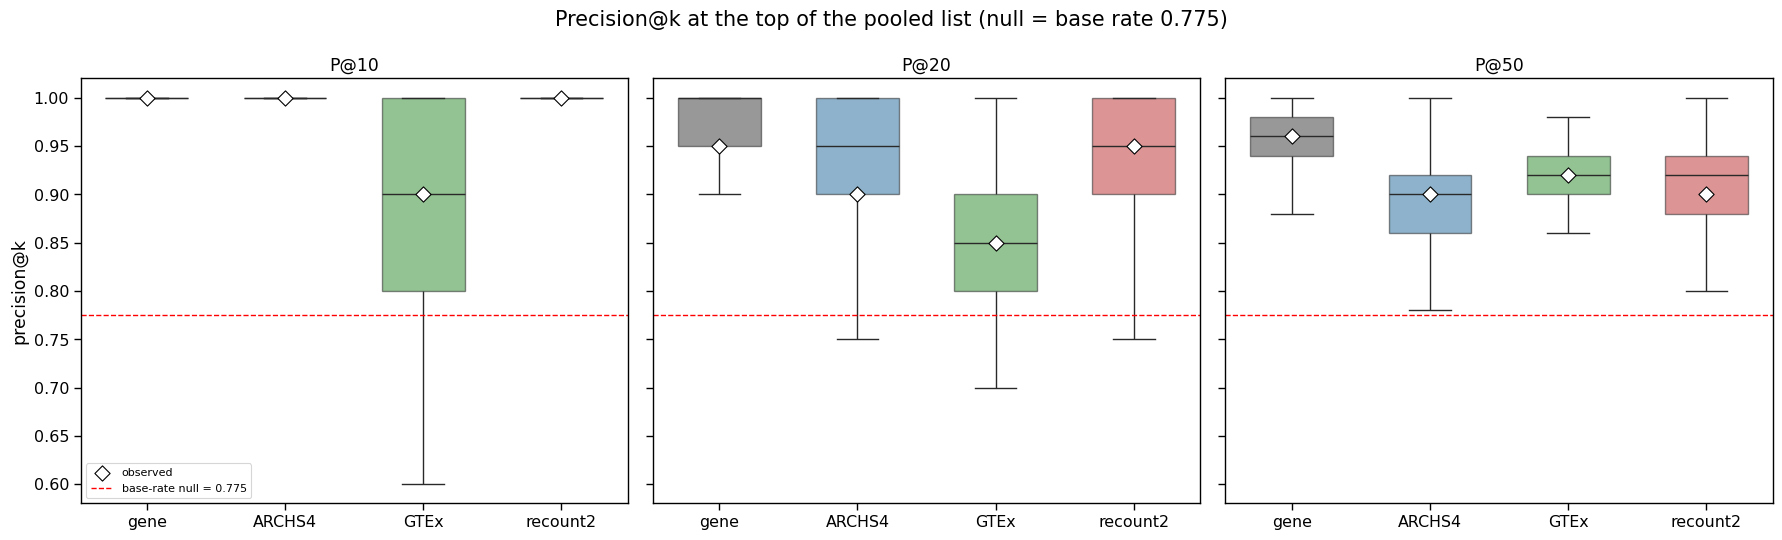

In [12]:
# --- precision@k bootstrap distributions, faceted by k ---
pk_names = [f'P@{k}' for k in PK_KS]
with sns.plotting_context('paper', font_scale=1.3):
    fig, axes = plt.subplots(1, len(pk_names), figsize=(6 * len(pk_names), 5.5), sharey=True)
    axes = list(np.atleast_1d(axes))
    for ax, name in zip(axes, pk_names):
        d = pd.DataFrame({m: boot_metric[name][m] for m in order}).melt(
            var_name='method', value_name='pk')
        sns.boxplot(data=d, x='method', y='pk', order=order, ax=ax,
                    palette=palette, showfliers=False, width=0.6, boxprops=dict(alpha=0.55))
        obs = [obs_metric[name][m] for m in order]
        ax.scatter(range(len(order)), obs, marker='D', s=60, color='white',
                   edgecolor='black', zorder=10, label='observed')
        ax.axhline(base_rate, color='red', linestyle='--', linewidth=1,
                   label=f'base-rate null = {base_rate:.3f}')
        ax.set_title(name)
        ax.set_xlabel('')
        ax.set_xticklabels(labels)
        ax.set_ylabel('precision@k')
    axes[0].legend(loc='lower left', fontsize=8)
    fig.suptitle('Precision@k at the top of the pooled list (null = base rate 0.775)')
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'early_enrichment_pk_dist.png', dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()

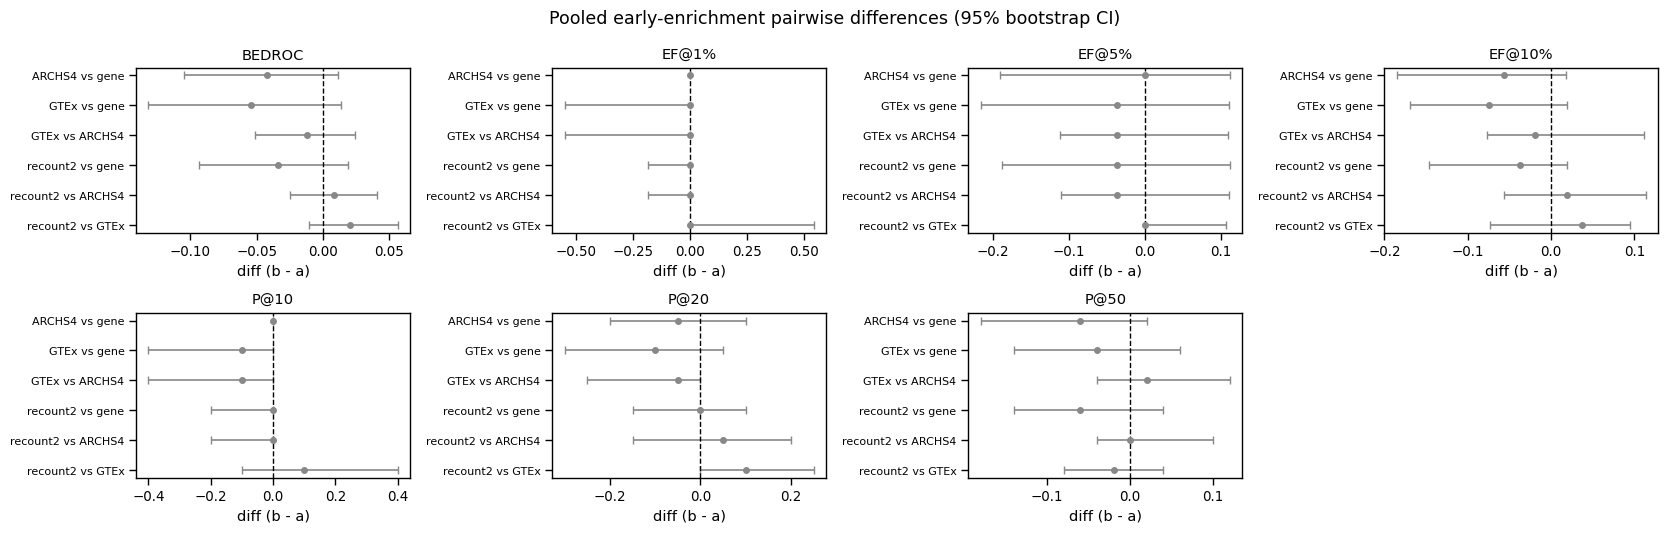

In [13]:
# --- Forest of pairwise differences, one panel per metric ---
ncol = 4
nrow = int(np.ceil(len(METRIC_ORDER) / ncol))
with sns.plotting_context('paper', font_scale=1.1):
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 2.7 * nrow), squeeze=False)
    for ax_i, mname in enumerate(METRIC_ORDER):
        ax = axes[ax_i // ncol][ax_i % ncol]
        sub = results[results['metric'] == mname].reset_index(drop=True)
        ypos = np.arange(len(sub))[::-1]
        for y, (_, r) in zip(ypos, sub.iterrows()):
            color = '#C44E52' if r['ci_excludes_0'] else '#888888'
            ax.errorbar(r['diff_obs'], y,
                        xerr=[[r['diff_obs'] - r['diff_ci_lo']],
                              [r['diff_ci_hi'] - r['diff_obs']]],
                        fmt='o', color=color, ecolor=color, capsize=3, markersize=4)
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.set_yticks(ypos)
        ax.set_yticklabels([f"{METHOD_LABEL[r['method_b']]} vs {METHOD_LABEL[r['method_a']]}"
                            for _, r in sub.iterrows()], fontsize=8)
        ax.set_title(mname)
        ax.set_xlabel('diff (b - a)')
    for j in range(len(METRIC_ORDER), nrow * ncol):
        axes[j // ncol][j % ncol].axis('off')
    fig.suptitle('Pooled early-enrichment pairwise differences (95% bootstrap CI)')
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'early_enrichment_diff_forest.png', dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()

# Write FINDINGS.md

In [14]:
def _fmt_obs(mname):
    return ', '.join(f'{METHOD_LABEL[m]}={obs_metric[mname][m]:.4f}' for m in METHOD_ORDER)


def _fmt_diff_rows(mname):
    sub = results[results['metric'] == mname]
    lines = []
    for _, r in sub.iterrows():
        sig = 'SIGNIFICANT' if r['p_value_bh'] < 0.05 else 'n.s.'
        lines.append(
            f"- {METHOD_LABEL[r['method_b']]} vs {METHOD_LABEL[r['method_a']]}: "
            f"diff={r['diff_obs']:+.4f} [{r['diff_ci_lo']:+.4f}, {r['diff_ci_hi']:+.4f}], "
            f"p={r['p_value']:.3f} (BH {r['p_value_bh']:.3f}) -> {sig}")
    return '\n'.join(lines)


bedroc_order = sorted(METHOD_ORDER, key=lambda m: obs_metric['BEDROC'][m], reverse=True)
bedroc_order_str = ' > '.join(f'{METHOD_LABEL[m]} {obs_metric["BEDROC"][m]:.3f}' for m in bedroc_order)

sig = results[results['p_value_bh'] < 0.05]
if len(sig) == 0:
    sig_summary = ('No pairwise difference is BH-significant for any early-enrichment '
                   'metric (every 95% CI crosses 0).')
else:
    parts = [f"{METHOD_LABEL[r['method_b']]} vs {METHOD_LABEL[r['method_a']]} "
             f"({r['metric']}: diff={r['diff_obs']:+.3f}, BH p={r['p_value_bh']:.3f})"
             for _, r in sig.iterrows()]
    sig_summary = 'BH-significant: ' + '; '.join(parts) + '.'

K_list = ', '.join(f'{int(round(c * 100))}%->{int(np.ceil(c * n))}' for c in EF_CHIS)

text = f'''# Findings -- pooled early-enrichment (BEDROC, EF, precision@k)

Scope: POOLED GLOBAL -- all {n} (drug, disease) pairs ranked together by score, the
TOP of the list evaluated (not per-disease). 4 methods, from
`../signif_test/predictions_paired.pkl`. Paired bootstrap N={N_BOOT} (seed {SEED}),
resampling **pairs** (same resample applied to every method; diffs by subtraction,
BH within each metric family). Headline = BEDROC(alpha={BEDROC_ALPHA:.0f}); EF@1/5/10%
(K = {K_list}) and precision@{{10,20,50}} for interpretability.

## HEADLINE CAVEAT -- high prevalence, low headroom (read first)
The pooled base rate is {n_pos}/{n} = {base_rate:.3f} positive. This is the INVERSE of
the rare-positive regime early-enrichment metrics were designed for (virtual screening,
~0.1-1% actives), so absolute values sit near a ceiling for every method:
- random-baseline **BEDROC = base rate ~ {base_rate:.3f}** (NOT 0.5); perfect = 1.0 ->
  only ~{1 - base_rate:.3f} of headroom, so BEDROC differences are compressed.
- **EF ceiling = 1/base_rate = {EF_MAX:.3f}**; random EF = 1.0 -> at most ~{(EF_MAX - 1) * 100:.0f}% enrichment is possible.
- precision@k null = {base_rate:.3f}.
The interpretable quantity is therefore the **paired difference** between methods at the
top (both face the same ceiling, so the subtraction is meaningful), not the absolute level.

## Observed pooled metrics by method
- BEDROC(alpha={BEDROC_ALPHA:.0f}):  {_fmt_obs('BEDROC')}   (null ~ {base_rate:.3f}, max 1.0)
- EF@1%: {_fmt_obs('EF@1%')}  |  EF@5%: {_fmt_obs('EF@5%')}  |  EF@10%: {_fmt_obs('EF@10%')}   (null 1.0, ceiling {EF_MAX:.3f})
- P@10: {_fmt_obs('P@10')}  |  P@20: {_fmt_obs('P@20')}  |  P@50: {_fmt_obs('P@50')}   (null {base_rate:.3f})
- BEDROC ordering (high->low): {bedroc_order_str}

## Pairwise differences (paired bootstrap, diff = b - a, BH within each metric)
### BEDROC
{_fmt_diff_rows('BEDROC')}
### EF@1%
{_fmt_diff_rows('EF@1%')}
### EF@5%
{_fmt_diff_rows('EF@5%')}
### EF@10%
{_fmt_diff_rows('EF@10%')}
### P@10
{_fmt_diff_rows('P@10')}
### P@20
{_fmt_diff_rows('P@20')}
### P@50
{_fmt_diff_rows('P@50')}

## Read
- **Significance:** {sig_summary}
- **Early enrichment tells a different story than AUROC.** Pooled AUROC ordered the
  methods ARCHS4 > recount2 > GTEx > gene (none significant; `../signif_test`). At the
  very TOP of the list the BEDROC ordering is {bedroc_order_str} -- the single-gene
  baseline ranks true treatments at the top at least as densely as the LV models (it has
  the numerically highest BEDROC); whether that lead is reliable is reported above.
  So switching the headline to the repurposing-relevant early region does NOT hand the LV
  models an advantage -- it reinforces the H4 null (no method is reliably best).
- **The metric choice matters more than the method here.** Absolute BEDROC is well above
  the {base_rate:.3f} null for every method (the top of the list IS genuinely enriched),
  but the high prevalence caps how much daylight any method can open over another.

## Caveats
- **HIGH-PREVALENCE / LOW-HEADROOM is the dominant limitation** (see headline caveat):
  EF cannot exceed {EF_MAX:.3f}; BEDROC/precision nulls sit at {base_rate:.3f}. Early-
  enrichment was built for rare positives; here positives dominate, so read DIFFERENCES.
- **precision@k is coarse under the bootstrap**, especially P@10: it takes only 11 distinct
  values (0/10 .. 10/10), so its CI is granular and paired diffs are multiples of 0.1.
  P@50 and EF@10% (K = {int(np.ceil(0.10 * n))}) are smoother; BEDROC is continuous and is
  the headline for that reason.
- **Ties** are broken deterministically by input order (stable argsort); with float
  mean-of-rank scores exact ties are rare, so this shifts a cut by at most +-1 item.
- **Pooled list mixes diseases of very different size/prevalence**, so a few large, easy
  diseases can dominate the global top-k. `../per_disease_test` isolates the per-disease
  view (more headroom; base rates 0.36-0.95) and is the complementary use-case framing.
- **Methods share inputs** (S-PrediXcan / LINCS): the paired bootstrap handles the
  cross-method correlation, but this is not independent replication.
'''

out_md = OUTPUT_DIR / 'FINDINGS.md'
out_md.write_text(text)
display(out_md)
print(text)

PosixPath('/home/miltondp/projects/clamp/clamp-analyses/output/03_model_biology/00_archs4/02_drug_disease_associations/early_enrichment_test/FINDINGS.md')

# Findings -- pooled early-enrichment (BEDROC, EF, precision@k)

Scope: POOLED GLOBAL -- all 685 (drug, disease) pairs ranked together by score, the
TOP of the list evaluated (not per-disease). 4 methods, from
`../signif_test/predictions_paired.pkl`. Paired bootstrap N=10000 (seed 42),
resampling **pairs** (same resample applied to every method; diffs by subtraction,
BH within each metric family). Headline = BEDROC(alpha=20); EF@1/5/10%
(K = 1%->7, 5%->35, 10%->69) and precision@{10,20,50} for interpretability.

## HEADLINE CAVEAT -- high prevalence, low headroom (read first)
The pooled base rate is 531/685 = 0.775 positive. This is the INVERSE of
the rare-positive regime early-enrichment metrics were designed for (virtual screening,
~0.1-1% actives), so absolute values sit near a ceiling for every method:
- random-baseline **BEDROC = base rate ~ 0.775** (NOT 0.5); perfect = 1.0 ->
  only ~0.225 of headroom, so BEDROC differences are compressed.
- **EF ceiling = 1/base_rate = 1.290**; 